In [1]:
import torch
import torch.nn as nn
from torchvision.datasets import CIFAR10
from torchvision.transforms import Compose, Normalize, ToTensor
from torch.utils.data import DataLoader
from torch.nn import init
import matplotlib.pyplot as plt
device = 'cuda:0'

In [2]:
# only has train and test set
# 1D data, so mean and std parameter contain only one element.
data_transform = Compose(transforms=[ToTensor(),
                                     Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

# prepare data
trainset = CIFAR10(root='data',
                        train=True,
                        transform=data_transform,
                        download=True)

testset = CIFAR10(root='data',
                       train=False,
                       transform=data_transform)

# convert to DataLoader. Shuffle train set and doesn't turn on it for test set
trainloader = DataLoader(dataset=trainset,
                         batch_size=1024,
                         shuffle=True,
                         num_workers=10,
                         drop_last=True)

testloader = DataLoader(dataset=testset,
                        batch_size=1024,
                        shuffle=False,
                        num_workers=10,
                        drop_last=True)


# for debug
for _, (X_sample,y_sample) in enumerate(trainloader):
    print(X_sample.shape, y_sample.shape)
    break

100%|██████████| 170M/170M [00:03<00:00, 43.6MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


torch.Size([1024, 3, 32, 32]) torch.Size([1024])


In [3]:
# setup for CNNs training - solution 03: use SwigGLU activation function. References: https://arxiv.org/pdf/1702.03118
classes = 10

block1 = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding='same'),  nn.SiLU(inplace=True),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same'), nn.SiLU(inplace=True),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same'), nn.SiLU(inplace=True),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

block2 = nn.Sequential(
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'),  nn.SiLU(inplace=True),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same'), nn.SiLU(inplace=True),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same'), nn.SiLU(inplace=True),
    nn.MaxPool2d(kernel_size=2, stride=2)
)


block3 = nn.Sequential(
    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding='same'), nn.SiLU(inplace=True),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same'), nn.SiLU(inplace=True),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same'), nn.SiLU(inplace=True),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

block4 = nn.Sequential(
    nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding='same'), nn.SiLU(inplace=True),
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding='same'), nn.SiLU(inplace=True),
    nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding='same'), nn.SiLU(inplace=True),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=512*2*2, out_features=512), nn.SiLU(),
    nn.Linear(in_features=512, out_features=classes)
)


class CNNsTraining(nn.Module):
    def __init__(self):
        super(CNNsTraining, self).__init__()
        self.block1 = block1
        self.block2 = block2
        self.block3 = block3
        self.block4 = block4
        self.dense_layer = classifier

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.dense_layer(x)
        return x

In [4]:
# prepare to train
model = CNNsTraining().to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)

# parameters
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 8873994


In [5]:

def acc(logits_matrix, true_label_vector):
    """
    Calculate accuracy for model
    - logits_matrix:        a matrix which haves num_of_batch rows, and num_classes columns.
    - true_label_vector:    a vector contains true class of all samples in batch.
    """
    # get max value for each rows
    maxxing_vector = torch.argmax(logits_matrix, dim=1)

    # get the similar numbers between true and pred label, then calculates sum
    sum_elements = len(true_label_vector)
    similar_elements = (maxxing_vector == true_label_vector).sum()

    # accuracy
    acc_value = similar_elements/sum_elements
    return acc_value

In [6]:
# training
epochs = 50

# tracking best value
best_train_acc = 0
best_test_acc = 0
best_train_loss = 1000000
best_test_loss = 1000000

# train -- logging
train_losses = []
test_losses = []
train_accs = []
test_accs = []

for epoch in range(epochs):

    # batch logging
    train_loss_batches = []
    test_loss_batches = []
    train_acc_batches = []
    test_acc_batches = []
    #--------train field--------#
    model.train()
    for _, (X_train_batch, y_train_batch) in enumerate(trainloader):

        # transform to GPU
        X_train_batch, y_train_batch = X_train_batch.to(device), y_train_batch.to(device)

        # forward
        y_train_batch_pred = model(X_train_batch)                # output: logits matrix
        train_loss_batch = criterion(y_train_batch_pred, y_train_batch)

        # backward
        optimizer.zero_grad()
        train_loss_batch.backward()
        optimizer.step()

        # save loss result
        loss_batch_value = train_loss_batch.item()
        train_loss_batches.append(loss_batch_value)

        # save metric result
        try:
            train_acc_batch = acc(logits_matrix=y_train_batch_pred,
                              true_label_vector= y_train_batch)
            train_acc_batches.append(train_acc_batch)

        except Exception as e:
            print(f'Failed to calculate metric for training: {e}')


    # loss: train epoch logging
    train_loss_epoch = sum(train_loss_batches)/len(train_loss_batches)
    train_losses.append(train_loss_epoch)
    if train_loss_epoch < best_train_loss:
        best_train_loss = train_loss_epoch

    # metric: train epoch logging
    train_acc_epoch = sum(train_acc_batches)/len(train_acc_batches)
    train_accs.append(train_acc_epoch)
    if train_acc_epoch > best_train_acc:
        best_train_acc = train_acc_epoch


    #---------test field--------#
    model.eval()
    for _, (X_test_batch, y_test_batch) in enumerate(testloader):

        # transform to GPU
        X_test_batch, y_test_batch = X_test_batch.to(device), y_test_batch.to(device)

        # testing
        y_test_batch_pred = model(X_test_batch)
        test_loss_batch = criterion(y_test_batch_pred, y_test_batch)

        # save loss result
        test_loss_batch_value = test_loss_batch.item()
        test_loss_batches.append(test_loss_batch_value)

        # save metric result
        test_acc_batch = acc(logits_matrix=y_test_batch_pred,
                             true_label_vector=y_test_batch)
        test_acc_batches.append(test_acc_batch)


    # loss: test epoch logging
    test_loss_epoch = sum(test_loss_batches)/len(test_loss_batches)
    test_losses.append(test_loss_epoch)
    if test_loss_epoch < best_test_loss:
        best_test_loss = test_loss_epoch

    # metric: test epoch logging
    test_acc_epoch = sum(test_acc_batches)/len(test_acc_batches)
    test_accs.append(test_acc_epoch)
    if test_acc_epoch > best_test_acc:
        best_test_acc = test_acc_epoch


    # log
    print(f'EPOCH {epoch + 1}:           train_loss = {train_loss_epoch},                 test_loss = {test_loss_epoch}')

EPOCH 1:           train_loss = 2.3859492540359497,                 test_loss = 2.3715475135379367
EPOCH 2:           train_loss = 2.202034577727318,                 test_loss = 2.049734936820136
EPOCH 3:           train_loss = 1.9642466455698013,                 test_loss = 1.8263146744834051
EPOCH 4:           train_loss = 1.7907585551341374,                 test_loss = 1.694521254963345
EPOCH 5:           train_loss = 1.66597481071949,                 test_loss = 1.6017242405149672
EPOCH 6:           train_loss = 1.572173108657201,                 test_loss = 1.5272495084338717
EPOCH 7:           train_loss = 1.4523068418105443,                 test_loss = 1.4513707558314006
EPOCH 8:           train_loss = 1.4981261988480885,                 test_loss = 1.478181587325202
EPOCH 9:           train_loss = 1.3653788194060326,                 test_loss = 1.3068806727727253
EPOCH 10:           train_loss = 1.2211009189486504,                 test_loss = 1.2271303865644667
EPOCH 11:       

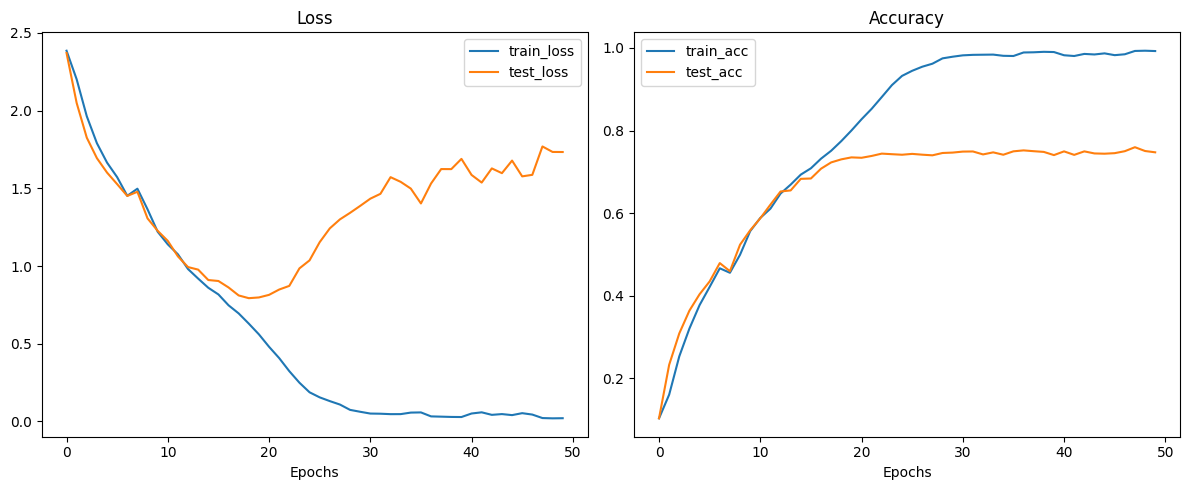

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss plot
ax1.plot([t.item() if torch.is_tensor(t) else t for t in train_losses], label='train_loss')
ax1.plot([t.item() if torch.is_tensor(t) else t for t in test_losses], label='test_loss')
ax1.set_xlabel('Epochs')
ax1.legend()
ax1.set_title("Loss")

# Accuracy plot
ax2.plot([t.item() if torch.is_tensor(t) else t for t in train_accs], label='train_acc')
ax2.plot([t.item() if torch.is_tensor(t) else t for t in test_accs], label='test_acc')
ax2.set_xlabel('Epochs')
ax2.legend()
ax2.set_title("Accuracy")

plt.tight_layout()
plt.show()

In [16]:
print("-------Best Performance--------\n")
print("Training Accuracy: {}%".format(round(best_train_acc.item()*100, 4)))
print("Training Loss: {}\n".format(round(best_train_loss, 4)))

print("Testing Accuracy: {}%".format(round(best_test_acc.item()*100, 4)))
print("Testing Loss: {}".format(round(best_test_loss, 4)))

-------Best Performance--------

Training Accuracy: 99.3225%
Training Loss: 0.0203

Testing Accuracy: 75.9657%
Testing Loss: 0.7935
